# EHR (Ehitisregister) Data Exploration - TalTech Campus Buildings

This notebook explores building physical parameters from the **Estonian Building Registry (EHR / Ehitisregister)**. Each TalTech campus building has an EHR code that links to detailed building data including:

- **Physical dimensions**: height, width, length, gross volume, footprint area, net closed area
- **Floor information**: min/max number of floors, number of elevators
- **Construction materials**: foundation type, load-bearing structure, wall type, roof type, floor slab type
- **Technical systems**: heating type, heat source, ventilation, cooling, water supply, sewage, electricity, gas
- **Energy certificates**: energy class (A-G), certificate dates
- **Building usage**: classification (KAOS code), first use year
- **Geometry**: building polygon coordinates

## Data Source

The EHR provides a public REST API:
- **UI**: `https://livekluster.ehr.ee/ui/ehr/v1/building/<EHR_CODE>`
- **API**: `https://livekluster.ehr.ee/api/building/v2/buildingData?ehr_code=<EHR_CODE>`
- **Swagger docs**: `https://swaggerui.ehr.ee/avaandmete_api`

The EHR codes for each TalTech campus building are stored in `data/campus-data/hooned koodid.xlsx` as hyperlinks in the "EHR register" column.

In [32]:
%pip install openpyxl pandas requests

Note: you may need to restart the kernel to use updated packages.


In [33]:
# Imports

from pathlib import Path
import re
import json
import time

import pandas as pd
from openpyxl import load_workbook
import requests

## 1. Load Building Codes and Extract EHR Codes

Load the building codes from the campus data Excel file and extract the EHR codes from the hyperlinked URLs.

In [34]:
# Paths
CAMPUS_DATA_DIR = Path("data/campus-data")
CAMPUS_BUILDING_CODES_FILE = CAMPUS_DATA_DIR / "hooned koodid.xlsx"

# Load building codes
building_codes_df = pd.read_excel(CAMPUS_BUILDING_CODES_FILE)

# Extract hyperlinks from Excel (column B = "EHR register")
wb = load_workbook(CAMPUS_BUILDING_CODES_FILE, data_only=False)
ws = wb.active

hyperlinks = []
for row_idx in range(2, ws.max_row + 1):
    cell = ws[f"B{row_idx}"]
    url = cell.hyperlink.target if cell.hyperlink else None
    hyperlinks.append(url)

building_codes_df["EHR register URL"] = hyperlinks[:len(building_codes_df)]

# Extract EHR code from URL (last part of the path: .../building/101026149)
def extract_ehr_code(url):
    if url is None:
        return None
    match = re.search(r'/building/(\d+)', url)
    return match.group(1) if match else None

building_codes_df["ehr_code"] = building_codes_df["EHR register URL"].apply(extract_ehr_code)

# Clean up column names for clarity
building_codes_df = building_codes_df.rename(columns={
    "kood": "campus_code",
    "Hoone": "building_name",
    "Unnamed: 3": "full_address",
    "Unnamed: 4": "short_address",
})

# Display the building codes with EHR codes
print(f"Found {len(building_codes_df)} buildings with {building_codes_df['ehr_code'].notna().sum()} EHR codes\n")
building_codes_df[["campus_code", "building_name", "short_address", "ehr_code", "EHR register URL"]]

Found 16 buildings with 16 EHR codes



,campus_code,building_name,short_address,ehr_code,EHR register URL
0,U01,õppehoone nr 1,Ehitajate tee 5/1,101026153,https://livekluster.ehr.ee/ui/ehr/v1/building/...
1,U02 (+U02B),TTÜ õppehoone nr 2,Ehitajate tee 5/2,101026150,https://livekluster.ehr.ee/ui/ehr/v1/building/...
2,U03 (+U03B),õppehoone nr 3,Ehitajate tee 5/3,101026151,https://livekluster.ehr.ee/ui/ehr/v1/building/...
3,U04,õppehoone nr 4,Ehitajate tee 5/4,101026152,https://livekluster.ehr.ee/ui/ehr/v1/building/...
4,U04B,õppehoone n 4B,Ehitajate tee 5/8,101026655,https://livekluster.ehr.ee/ui/ehr/v1/building/...
5,U05,TTÜ teadus-õppehoone V korpus galeriidega,Ehitajate tee 5/5,101026146,https://livekluster.ehr.ee/ui/ehr/v1/building/...
6,U05B,õppehoone nr 5B,Ehitajate tee 5/7,101026656,https://livekluster.ehr.ee/ui/ehr/v1/building/...
7,U06 (+U06A),õppehoone nr 6,Ehitajate tee 5/6,101026149,https://livekluster.ehr.ee/ui/ehr/v1/building/...
8,GEO,TTÜ Hoonetekompleksi III ja IV korpuse vahehoone,Ehitajate tee 5/9,120296180,https://livekluster.ehr.ee/ui/ehr/v1/building/...
9,STU,TTÜ üliõpilasmaja,Ehitajate tee 5,120599499,https://livekluster.ehr.ee/ui/ehr/v1/building/...


## 2. Query EHR API for All Buildings

Fetch detailed building data from the EHR public API for each building. The API returns comprehensive JSON data with physical parameters, technical indicators, energy certificates, and more.

**API endpoint**: `https://livekluster.ehr.ee/api/building/v2/buildingData?ehr_code=<CODE>`

In [35]:
EHR_API_BASE = "https://livekluster.ehr.ee/api/building/v2/buildingData"

def fetch_ehr_building_data(ehr_code: str, timeout: int = 30) -> dict:
    """Fetch building data from the EHR API for a given EHR code."""
    url = f"{EHR_API_BASE}?ehr_code={ehr_code}"
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return response.json()

# Fetch data for all buildings with EHR codes
ehr_data = {}
buildings_with_codes = building_codes_df[building_codes_df["ehr_code"].notna()]

print(f"Fetching EHR data for {len(buildings_with_codes)} buildings...\n")

for _, row in buildings_with_codes.iterrows():
    campus_code = row["campus_code"]
    ehr_code = row["ehr_code"]
    try:
        data = fetch_ehr_building_data(ehr_code)
        ehr_data[campus_code] = data
        print(f"  OK  {campus_code:15s} (EHR: {ehr_code}) - {row['building_name']}")
        time.sleep(0.5)  # Be polite to the API
    except Exception as e:
        print(f"  FAIL {campus_code:15s} (EHR: {ehr_code}) - {e}")

print(f"\nSuccessfully fetched data for {len(ehr_data)}/{len(buildings_with_codes)} buildings")

Fetching EHR data for 16 buildings...

  OK  U01             (EHR: 101026153) - õppehoone nr 1
  OK  U02 (+U02B)     (EHR: 101026150) - TTÜ õppehoone nr 2
  OK  U03 (+U03B)     (EHR: 101026151) - õppehoone nr 3
  OK  U04             (EHR: 101026152) - õppehoone nr 4
  OK  U04B            (EHR: 101026655) - õppehoone n 4B
  OK  U05             (EHR: 101026146) - TTÜ teadus-õppehoone V korpus galeriidega
  OK  U05B            (EHR: 101026656) - õppehoone nr 5B
  OK  U06 (+U06A)     (EHR: 101026149) - õppehoone nr 6
  OK  GEO             (EHR: 120296180) - TTÜ Hoonetekompleksi III ja IV korpuse vahehoone
  OK  STU             (EHR: 120599499) - TTÜ üliõpilasmaja
  OK  NRG             (EHR: 120224494) - TTÜ Energeetikateaduskonna hoone Ehitajate tee 5
  OK  LIB             (EHR: 120551286) - raamatukogu hoone
  OK  SOC             (EHR: 120546679) - TTÜ MH õppehoone
  OK  ICT             (EHR: 120308870) - TEHNOPOLIS-3 hoone Akadeemia tee 15a
  OK  ICO             (EHR: 120311624) - TTÜ IT

In [36]:
# Quick peek at the raw JSON structure for one building
sample_code = list(ehr_data.keys())[0]
sample = ehr_data[sample_code]

print(f"Sample building: {sample_code}")
print(f"Top-level keys: {list(sample.get('ehitis', {}).keys())}")
print()

# Show the main data sections
ehitis = sample["ehitis"]
for key in ehitis:
    val = ehitis[key]
    if isinstance(val, dict):
        print(f"  {key}: dict with keys {list(val.keys())[:5]}{'...' if len(val) > 5 else ''}")
    else:
        print(f"  {key}: {type(val).__name__}")

Sample building: U01
Top-level keys: ['ehitiseKujud', 'ehitiseAndmed', 'ehitiseKehand', 'ehitiseAadressid', 'ehitisePohiandmed', 'ehitiseEnergiamargised', 'ehitiseKatastriyksused', 'ehitiseKasutusotstarbed', 'ehitiseEnergiamargisedV3', 'ehitiseTehnilisedNaitajad']

  ehitiseKujud: dict with keys ['ruumikuju']
  ehitiseAndmed: dict with keys ['url', 'oper', 'adsOid', 'ehitId', 'ehrKood']...
  ehitiseKehand: dict with keys ['kehand']
  ehitiseAadressid: dict with keys ['aadress']
  ehitisePohiandmed: dict with keys ['maakond', 'kinavald', 'ehAlustKp', 'mahtBruto', 'oletuslik']...
  ehitiseEnergiamargised: dict with keys ['energiamargis']
  ehitiseKatastriyksused: dict with keys ['ehitiseKatastriyksus']
  ehitiseKasutusotstarbed: dict with keys ['kasutusotstarve']
  ehitiseEnergiamargisedV3: dict with keys ['energiamargis']
  ehitiseTehnilisedNaitajad: dict with keys ['tehnilineNaitaja']


## 3. Parse Physical Parameters (ehitisePohiandmed)

Extract the core physical dimensions and characteristics of each building. These are crucial for understanding how building geometry and size impact energy consumption.

Key fields:
- `korgus` - Height (m)
- `laius` - Width (m)
- `pikkus` - Length (m)
- `mahtBruto` - Gross volume (m³)
- `ehitisalunePind` - Footprint/ground area (m²)
- `suletud_netopind` / `koetavPind` - Net closed area / heated area (m²)
- `maxKorrusteArv` / `minKorrusteArv` - Max/min number of floors
- `lift` - Number of elevators

In [37]:
def parse_physical_params(campus_code: str, data: dict) -> dict:
    """Extract physical parameters from EHR API response."""
    ehitis = data.get("ehitis", {})
    andmed = ehitis.get("ehitiseAndmed", {})
    pohi = ehitis.get("ehitisePohiandmed", {})

    def safe_float(val):
        try:
            return float(val) if val is not None else None
        except (ValueError, TypeError):
            return None

    def safe_int(val):
        try:
            return int(val) if val is not None else None
        except (ValueError, TypeError):
            return None

    return {
        "campus_code": campus_code,
        "ehr_code": andmed.get("ehrKood"),
        "name": andmed.get("nimetus"),
        "address": andmed.get("taisaadress"),
        "building_type": andmed.get("kaosIdTxt"),  # Building classification text
        "kaos_code": andmed.get("kaosKood"),  # KAOS classification code
        "status": andmed.get("seisundTxt"),  # Building status (e.g., "Püstitamisel", "Kasutusel")
        "first_use_year": andmed.get("esmaneKasutus"),  # Year of first use
        # Physical dimensions
        "height_m": safe_float(pohi.get("korgus")),
        "width_m": safe_float(pohi.get("laius")),
        "length_m": safe_float(pohi.get("pikkus")),
        "gross_volume_m3": safe_float(pohi.get("mahtBruto")),
        "footprint_area_m2": safe_float(pohi.get("ehitisalunePind")),
        "heated_area_m2": safe_float(pohi.get("koetavPind")),
        "net_closed_area_m2": safe_float(pohi.get("suletud_netopind")),
        # Floor information
        "max_floors": safe_int(pohi.get("maxKorrusteArv")),
        "min_floors": safe_int(pohi.get("minKorrusteArv")),
        "elevators": safe_int(pohi.get("lift")),
        "rooms_count": safe_int(pohi.get("tubadeArv")),
        # Additional
        "non_residential_count": safe_int(pohi.get("mitteeluruumideArv")),
        "ownership_type": pohi.get("omandiLiikTxt"),
    }

# Parse physical parameters for all buildings
physical_rows = []
for campus_code, data in ehr_data.items():
    physical_rows.append(parse_physical_params(campus_code, data))

physical_df = pd.DataFrame(physical_rows)

# Display
print(f"Physical parameters for {len(physical_df)} buildings:\n")
physical_df

Physical parameters for 16 buildings:



,campus_code,ehr_code,name,address,building_type,kaos_code,status,first_use_year,height_m,width_m,...,gross_volume_m3,footprint_area_m2,heated_area_m2,net_closed_area_m2,max_floors,min_floors,elevators,rooms_count,non_residential_count,ownership_type
0,U01,101026153,õppehoone nr 1,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,1968,NaN,NaN,...,21780.0,1030.0,4088.7,4088.7,2,NaN,NaN,0,0,kinnisasi
1,U02 (+U02B),101026150,TTÜ õppehoone nr 2,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1967,17.2,37.2,...,24136.0,1931.0,24136.0,5388.8,4,2.0,1.0,0,0,kinnisasi
2,U03 (+U03B),101026151,õppehoone nr 3,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1966,17.3,11.4,...,30456.0,2826.0,5908.0,7145.5,4,3.0,1.0,0,0,kinnisasi
3,U04,101026152,õppehoone nr 4,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1965,18.7,12.0,...,24521.0,1736.0,5777.1,5777.1,4,2.0,1.0,0,0,kinnisasi
4,U04B,101026655,õppehoone n 4B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,1986,NaN,NaN,...,6360.0,740.0,NaN,1415.3,2,2.0,0.0,0,0,kinnisasi
5,U05,101026146,TTÜ teadus-õppehoone V korpus galeriidega,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1964,18.2,95.3,...,29705.0,2096.0,5550.0,5550.0,5,2.0,1.0,0,0,kinnisasi
6,U05B,101026656,õppehoone nr 5B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,2000,NaN,NaN,...,11539.0,794.0,NaN,2577.3,4,4.0,0.0,0,0,kinnisasi
7,U06 (+U06A),101026149,õppehoone nr 6,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Püstitamisel,1986,18.4,61.4,...,61946.0,3940.4,12841.2,12841.2,5,2.0,2.0,0,0,kinnisasi
8,GEO,120296180,TTÜ HOONETEKOMPLEKSI III JA IV KORPUSE VAHEHOO...,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,2006,4.2,12.8,...,3875.0,719.0,898.2,912.1,2,1.0,1.0,0,0,kinnisasi
9,STU,120599499,külmaseade,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu erihoone,12749,Olemas,2011,3.7,2.5,...,39.0,18.9,NaN,14.4,1,1.0,NaN,0,0,kinnisasi


In [38]:
# Key physical dimensions summary
key_cols = ["campus_code", "name", "first_use_year", "height_m", "width_m", "length_m",
            "gross_volume_m3", "footprint_area_m2", "heated_area_m2", "max_floors", "min_floors", "elevators"]
print("Key physical dimensions:\n")
physical_df[key_cols].to_string(index=False)

Key physical dimensions:



'campus_code                                                             name first_use_year  height_m  width_m  length_m  gross_volume_m3  footprint_area_m2  heated_area_m2  max_floors  min_floors  elevators\n        U01                                                   õppehoone nr 1           1968       NaN      NaN       NaN          21780.0             1030.0          4088.7           2         NaN        NaN\nU02 (+U02B)                                               TTÜ õppehoone nr 2           1967      17.2     37.2     111.4          24136.0             1931.0         24136.0           4         2.0        1.0\nU03 (+U03B)                                                   õppehoone nr 3           1966      17.3     11.4     100.4          30456.0             2826.0          5908.0           4         3.0        1.0\n        U04                                                   õppehoone nr 4           1965      18.7     12.0      83.3          24521.0             1736.0       

## 4. Parse Technical Indicators (ehitiseTehnilisedNaitajad)

These describe the construction materials and technical systems of each building. They are organized by classification code (`klKood`) and include:

**Construction (KONS_*):**
- `KONS_VUND` - Foundation type
- `KONS_KKONSTR` - Load-bearing/structural material
- `KONS_VALISV` - Exterior wall finish material
- `KONS_VSEIN` - Wall type
- `KONS_SARIKAD` - Roof/ceiling load-bearing material
- `KONS_VLAED` - Floor slab material
- `KONS_KATUS` - Roofing material

**Technical systems (TEHNO_*):**
- `TEHNO_SOOJAVLIIK` - Heating supply type
- `TEHNO_SOOJUSA` - Heat source
- `TEHNO_VENT` - Ventilation type
- `TEHNO_JAHUTUS` - Cooling system type
- `TEHNO_ELEKLIIK` - Electricity system type
- `TEHNO_VESI` - Water supply type
- `TEHNO_KANAL` - Sewage/drainage type
- `TEHNO_GAAS` - Gas availability

In [39]:
# Technical indicator classification codes and their English descriptions
TECH_INDICATOR_LABELS = {
    # Construction
    "KONS_VUND": "foundation_type",
    "KONS_KKONSTR": "structural_material",
    "KONS_VALISV": "exterior_finish_material",
    "KONS_VSEIN": "wall_type",
    "KONS_SARIKAD": "roof_structure_material",
    "KONS_VLAED": "floor_slab_material",
    "KONS_KATUS": "roofing_material",
    # Technical systems
    "TEHNO_SOOJAVLIIK": "heating_supply_type",
    "TEHNO_SOOJUSA": "heat_source",
    "TEHNO_VENT": "ventilation_type",
    "TEHNO_JAHUTUS": "cooling_system",
    "TEHNO_ELEKLIIK": "electricity_type",
    "TEHNO_VESI": "water_supply_type",
    "TEHNO_KANAL": "sewage_type",
    "TEHNO_GAAS": "gas_availability",
    # Cultural value
    "EHITIS_MALESTIS": "cultural_heritage",
}

def parse_technical_indicators(campus_code: str, data: dict) -> dict:
    """Extract technical indicators from EHR API response."""
    ehitis = data.get("ehitis", {})
    tech = ehitis.get("ehitiseTehnilisedNaitajad", {})
    indicators = tech.get("tehnilineNaitaja", [])

    result = {"campus_code": campus_code}

    # Group indicators by klKood
    for indicator in indicators:
        kl_kood = indicator.get("klKood", "")
        nimetus = indicator.get("nimetus", "")  # Estonian name/value
        kl_nimetus = indicator.get("klNimetus", "")  # Estonian classification name
        lisavaartus = indicator.get("lisavaartus")  # Additional value (e.g., specific material)

        col_name = TECH_INDICATOR_LABELS.get(kl_kood, kl_kood)

        # Some buildings have multiple values for the same klKood (e.g., multiple wall finishes)
        value = nimetus
        if lisavaartus:
            value = f"{nimetus} ({lisavaartus})"

        if col_name in result:
            # Append multiple values with " + "
            result[col_name] = f"{result[col_name]} + {value}"
        else:
            result[col_name] = value

        # Also store the Estonian classification name for reference
        result[f"{col_name}_est"] = kl_nimetus

    return result

# Parse technical indicators for all buildings
tech_rows = []
for campus_code, data in ehr_data.items():
    tech_rows.append(parse_technical_indicators(campus_code, data))

tech_df = pd.DataFrame(tech_rows)

# Display - only the main indicator columns (not _est suffix)
main_cols = ["campus_code"] + [col for col in tech_df.columns if not col.endswith("_est") and col != "campus_code"]
print(f"Technical indicators for {len(tech_df)} buildings:\n")
tech_df[main_cols]

Technical indicators for 16 buildings:



,campus_code,heating_supply_type,foundation_type,structural_material,floor_slab_material,heat_source,roof_structure_material,wall_type,TEHNO_ENERGIA,roofing_material,exterior_finish_material,water_supply_type,electricity_type,sewage_type,cultural_heritage,gas_availability,ventilation_type,cooling_system,TEHNO_KYTL,TEHNO_JAHUTUSA
0,U01,lokaalküte,madalvundament,"tellis + tellis, väikeplokk",monteeritav raudbetoon,katel,monteeritav raudbetoon,"tellis, väikeplokk",küttegaas (täpsustamata),bituumen või PVC plaat või rullmaterjal,looduslik kivi + keraamiline tellis,võrk,võrk + päikeseenergial põhinev,võrk,Ehitis asub mälestisel (8723),NaN,NaN,NaN,NaN,NaN
1,U02 (+U02B),lokaalküte + muu (õhkküte) + kaugküte,madalvundament,"monteeritav raudbetoon + tellis + tellis, väik...",monteeritav raudbetoon,katel + muu (õhkküte) + kaugküte,monteeritav raudbetoon,"tellis, väikeplokk",vedelkütus,bituumen või PVC plaat või rullmaterjal,krohv + muu (puhasvuuk siskaattellis),võrk,võrk,võrk,Ehitis asub mälestisel (8723),puudub,NaN,NaN,NaN,NaN
2,U03 (+U03B),kaugküte,madalvundament,metall + monoliitne raudbetoon + tellis,monoliitne raudbetoon + monteeritav raudbetoon,kaugküte,monoliitne raudbetoon + monteeritav raudbetoon,tellis,NaN,bituumen või PVC plaat või rullmaterjal,krohv + keraamiline tellis,võrk,võrk,võrk,Ehitis asub mälestisel (8723),puudub,soojustagastusega ventilatsioon,lokaalne jahutus,NaN,NaN
3,U04,lokaalküte,madalvundament,"metall + tellis + tellis, väikeplokk",plekkprofiil + terasferm või -tala + monteerit...,katel,plekkprofiil + terasferm või -tala + monteerit...,"tellis, väikeplokk",küttegaas (täpsustamata),bituumen või PVC plaat või rullmaterjal,krohv,võrk,võrk,võrk,Ehitis asub mälestisel (8723),olemas,NaN,NaN,NaN,NaN
4,U04B,kaugküte,madalvundament (vundament/20/),monteeritav raudbetoon (kandekonst/10/),monteeritav raudbetoon (vahelaed/10/),katel + kaugküte,monteeritav raudbetoon,"tellis, väikeplokk (valissein/30/)",vedelkütus (kytuseliik/1),bituumen või PVC plaat või rullmaterjal (kat...,keraamiline tellis (valis_viim/10/),võrk (kylm_vesi/1),võrk (elekter/2),võrk (kanalisats/1),NaN,olemas (gaas/1),NaN,NaN,NaN,NaN
5,U05,kaugküte,madalvundament,"tellis + monteeritav raudbetoon + tellis, väik...",monteeritav raudbetoon,katel + kaugküte,monteeritav raudbetoon,"tellis, väikeplokk",vedelkütus,bituumen või PVC plaat või rullmaterjal,krohv + keraamiline tellis + muu (klaas),võrk,võrk,võrk,Ehitis asub mälestisel (8723),puudub,NaN,NaN,NaN,NaN
6,U05B,kaugküte,madalvundament (vundament/20/),monteeritav raudbetoon (kandekonst/10/),monteeritav raudbetoon (vahelaed/10/),katel + kaugküte,monteeritav raudbetoon,"tellis, väikeplokk (valissein/30/)",vedelkütus (kytuseliik/1),bituumen või PVC plaat või rullmaterjal (kat...,keraamiline tellis (valis_viim/10/),võrk (kylm_vesi/1),võrk (elekter/2),võrk (kanalisats/1),NaN,puudub (gaas/0),NaN,NaN,NaN,NaN
7,U06 (+U06A),kaugküte,madalvundament,monteeritav raudbetoon,monteeritav raudbetoon,kaugküte,monteeritav raudbetoon,mitmekihiline raudbetoonpaneel,NaN,bituumen või PVC plaat või rullmaterjal,krohv + muu (tellis),võrk,võrk,võrk,Ehitis on mälestis (8723),olemas,soojustagastusega ventilatsioon,lokaalne jahutus,NaN,NaN
8,GEO,lokaalküte,madalvundament,monteeritav raudbetoon + tellis + monoliitne r...,monteeritav raudbetoon,katel,monteeritav raudbetoon,"tellis, väikeplokk",küttegaas (täpsustamata),bituumen või PVC plaat või rullmaterjal,keraamiline tellis + muu (õhekrohv),võrk,võrk,võrk,NaN,olemas,NaN,NaN,NaN,NaN
9,STU,puudub,madalvundament,metall + puit,terasferm või -tala + puit,puudub,terasferm või -tala + puit,profileeritud metall,puudub,plekk,metall (seal hulgas plekk või profiilplekk),puudub,võrk,puudub,NaN,puudub,NaN,NaN,NaN,NaN


In [40]:
# Show the Estonian classification names for reference (what each klKood means)
est_cols = ["campus_code"] + [col for col in tech_df.columns if col.endswith("_est")]
print("Estonian classification names (reference):\n")

# Show one row as reference for classification names
if len(tech_df) > 0:
    ref_row = tech_df[est_cols].iloc[0]
    for col, val in ref_row.items():
        if col != "campus_code" and pd.notna(val):
            clean_name = col.replace("_est", "")
            print(f"  {clean_name:30s} = {val}")

Estonian classification names (reference):

  heating_supply_type            = Soojusvarustuse liik
  foundation_type                = Vundamendi liik
  structural_material            = Kande- ja jäigastavate konstruktsioonide materjal
  floor_slab_material            = Vahelagede kandva osa materjal
  heat_source                    = Soojusallikas
  roof_structure_material        = Katuste ja katuselagede kandva osa materjal
  wall_type                      = Välisseina liik
  TEHNO_ENERGIA                  = Energiakandja
  roofing_material               = Katusekatte materjal
  exterior_finish_material       = Välisseina välisviimistluse materjal
  water_supply_type              = Veevarustuse liik
  electricity_type               = Elektrisüsteemi liik
  sewage_type                    = Kanalisatsiooni liik
  cultural_heritage              = Kultuuriväärtus


## 5. Parse Energy Certificates (ehitiseEnergiamargised)

Energy performance certificates (EPC) provide the energy class rating for each building (A to H, where A is most efficient). This directly relates to the building's thermal performance and energy consumption patterns.

In [41]:
def parse_energy_certificates(campus_code: str, data: dict) -> list:
    """Extract energy certificate data from EHR API response."""
    ehitis = data.get("ehitis", {})

    # Try both v1 and v3 energy certificate structures
    certs_v1 = ehitis.get("ehitiseEnergiamargised", {}).get("energiamargis", [])
    certs_v3 = ehitis.get("ehitiseEnergiamargisedV3", {}).get("energiamargis", [])

    results = []

    for cert in certs_v1:
        energy_class = cert.get("energiaKlass", "")
        cert_date = cert.get("energiaMargiseKp", "")
        issued_date = cert.get("energiaValjastKp", "")
        valid_until = cert.get("energiaKehtibKuniKp", "")
        doc_type = cert.get("dokLiik", "")
        doc_nr = cert.get("dok_nr", "")

        results.append({
            "campus_code": campus_code,
            "energy_class": energy_class,
            "certificate_date": cert_date[:10] if cert_date else None,
            "issued_date": issued_date[:10] if issued_date else None,
            "valid_until": valid_until[:10] if valid_until else None,
            "document_type": doc_type,
            "document_nr": doc_nr,
            "source": "v1",
        })

    # If no v1 certs, try v3
    if not results:
        for cert in certs_v3:
            energy_class_raw = cert.get("energiaKlass", "")
            # v3 format: "ENERGIAKL_D" -> "D"
            energy_class = energy_class_raw.replace("ENERGIAKL_", "") if energy_class_raw else ""
            cert_date = cert.get("energiaMargiseKp", "")
            issued_date = cert.get("energiaValjastKp", "")
            valid_until = cert.get("energiaKehtibKuniKp", "")
            doc_name = cert.get("dokNimetus", "")
            doc_nr = cert.get("dokNr", "")

            results.append({
                "campus_code": campus_code,
                "energy_class": energy_class,
                "certificate_date": cert_date[:10] if cert_date else None,
                "issued_date": issued_date[:10] if issued_date else None,
                "valid_until": valid_until[:10] if valid_until else None,
                "document_type": doc_name,
                "document_nr": doc_nr,
                "source": "v3",
            })

    return results

# Parse energy certificates for all buildings
energy_rows = []
for campus_code, data in ehr_data.items():
    certs = parse_energy_certificates(campus_code, data)
    if certs:
        energy_rows.extend(certs)
    else:
        energy_rows.append({
            "campus_code": campus_code,
            "energy_class": "N/A",
            "certificate_date": None,
            "issued_date": None,
            "valid_until": None,
            "document_type": "No certificate found",
            "document_nr": None,
            "source": None,
        })

energy_df = pd.DataFrame(energy_rows)

print(f"Energy certificates for {energy_df['campus_code'].nunique()} buildings:\n")
energy_df[["campus_code", "energy_class", "certificate_date", "issued_date", "document_type"]]

Energy certificates for 16 buildings:



,campus_code,energy_class,certificate_date,issued_date,document_type
0,U01,N/A,None,None,No certificate found
1,U02 (+U02B),N/A,None,None,No certificate found
2,U03 (+U03B),N/A,None,None,No certificate found
3,U04,N/A,None,None,No certificate found
4,U04B,N/A,None,None,No certificate found
5,U05,E,2011-05-18,2011-05-18,Energiaarvutusel põhineva energiamärgise teatis
6,U05B,N/A,None,None,No certificate found
7,U06 (+U06A),D,2011-12-19,2011-12-19,Energiaarvutusel põhineva energiamärgise teatis
8,GEO,N/A,None,None,No certificate found
9,STU,N/A,None,None,No certificate found


## 6. Parse Building Parts and Usage (ehitiseKehand, ehitiseKasutusotstarbed)

Building parts (kehand) describe the subdivision of the building into residential/non-residential units, and usage classification describes what the building is used for according to the KAOS system.

In [42]:
def parse_building_parts(campus_code: str, data: dict) -> list:
    """Extract building parts/units from EHR API response."""
    ehitis = data.get("ehitis", {})
    kehand_list = ehitis.get("ehitiseKehand", {}).get("kehand", [])

    parts = []
    for kehand in kehand_list:
        for osa in kehand.get("ehitiseOsad", {}).get("ehitiseOsa", []):
            parts.append({
                "campus_code": campus_code,
                "part_code": osa.get("osa_kood"),
                "part_type": osa.get("liikTxt"),  # Eluruum / Mitteeluruum
                "part_name": osa.get("nimetus"),
                "kaos_code": osa.get("kaosKood"),
                "kaos_name": osa.get("kaosNimetus"),
                "area_m2": float(osa.get("ehitiseOsaPohiandmed", {}).get("pind", 0) or 0),
            })
    return parts

def parse_usage(campus_code: str, data: dict) -> list:
    """Extract building usage classification from EHR API response."""
    ehitis = data.get("ehitis", {})
    usages = ehitis.get("ehitiseKasutusotstarbed", {}).get("kasutusotstarve", [])

    results = []
    for usage in usages:
        non_res_area = usage.get("mitteeluruumidePind")
        res_area = usage.get("eluruumidePind")
        results.append({
            "campus_code": campus_code,
            "kaos_code": usage.get("kaosKood"),
            "kaos_name": usage.get("kaosIdTxt"),
            "residential_area_m2": float(res_area) if res_area else None,
            "non_residential_area_m2": float(non_res_area) if non_res_area else None,
        })
    return results

# Parse building parts and usage
parts_rows = []
usage_rows = []
for campus_code, data in ehr_data.items():
    parts_rows.extend(parse_building_parts(campus_code, data))
    usage_rows.extend(parse_usage(campus_code, data))

parts_df = pd.DataFrame(parts_rows)
usage_df = pd.DataFrame(usage_rows)

print(f"Building parts ({len(parts_df)} entries across {parts_df['campus_code'].nunique()} buildings):\n")
display(parts_df)

print(f"\nBuilding usage classifications ({len(usage_df)} entries):\n")
usage_df

Building parts (22 entries across 16 buildings):



,campus_code,part_code,part_type,part_name,kaos_code,kaos_name,area_m2
0,U01,3745692,Mitteeluruum,õppehoone nr 1,12639,Muu haridus- või teadushoone,4017.8
1,U02 (+U02B),3745689,Mitteeluruum,TTÜ õppehoone nr 2,12634,"Ülikooli, rakenduskõrgkooli õppehoone",5388.8
2,U03 (+U03B),3745690,Mitteeluruum,õppehoone nr 3,12634,"Ülikooli, rakenduskõrgkooli õppehoone",7145.5
3,U04,3745691,Mitteeluruum,õppehoone nr 4,12634,"Ülikooli, rakenduskõrgkooli õppehoone",5777.1
4,U04B,3745693,Mitteeluruum,õppehoone n 4B,12639,Muu haridus- või teadushoone,1308.7
5,U05,3745686,Mitteeluruum,TTÜ teadus-õppehoone V korpus galeriidega,12634,"Ülikooli, rakenduskõrgkooli õppehoone",5550.0
6,U05B,3745694,Mitteeluruum,õppehoone nr 5B,12639,Muu haridus- või teadushoone,2303.3
7,U06 (+U06A),3745688,Mitteeluruum,õppehoone nr 6,12634,"Ülikooli, rakenduskõrgkooli õppehoone",12841.2
8,GEO,3745696,Mitteeluruum,TTÜ HOONETEKOMPLEKSI III JA IV KORPUSE VAHEHOO...,12639,Muu haridus- või teadushoone,912.1
9,STU,3745697,Mitteeluruum,külmaseade,12749,Muu erihoone,14.4



Building usage classifications (44 entries):



,campus_code,kaos_code,kaos_name,residential_area_m2,non_residential_area_m2
0,U01,12639,Muu haridus- või teadushoone,None,4017.8
1,U01,12639,Muu haridus- või teadushoone,None,NaN
2,U02 (+U02B),12634,"Ülikooli, rakenduskõrgkooli õppehoone",None,5388.8
3,U02 (+U02B),12634,"Ülikooli, rakenduskõrgkooli õppehoone",None,NaN
4,U03 (+U03B),12634,"Ülikooli, rakenduskõrgkooli õppehoone",None,7145.5
5,U03 (+U03B),12634,"Ülikooli, rakenduskõrgkooli õppehoone",None,NaN
6,U04,12634,"Ülikooli, rakenduskõrgkooli õppehoone",None,5777.1
7,U04,12634,"Ülikooli, rakenduskõrgkooli õppehoone",None,NaN
8,U04B,12639,Muu haridus- või teadushoone,None,1308.7
9,U04B,12639,Muu haridus- või teadushoone,None,NaN


## 7. Parse Building Geometry and Orientation (ehitiseKujud)

Extract the building footprint polygon, ground area, and **derive building orientation** from the geometry. The coordinates are in the Estonian national coordinate system (L-EST97 / EPSG:3301) where X=Easting and Y=Northing.

**Orientation method**: Find the longest edge of the building footprint polygon and compute its azimuth from North (clockwise). This approximates the main axis direction of the building. Orientation matters for solar gain patterns and wind exposure.

In [43]:
import math
import numpy as np

def compute_orientation(coords_ring):
    """
    Derive building orientation from its footprint polygon.

    Finds the longest edge of the polygon and computes its azimuth
    (angle from North, clockwise, 0-180°). This approximates the
    main axis orientation of the building.

    Coordinates are expected in L-EST97 (EPSG:3301) where X=Easting, Y=Northing.

    Returns:
        (azimuth_deg, longest_edge_length_m, orientation_label)
        azimuth_deg: 0° = N-S, 90° = E-W, values in [0, 180)
        orientation_label: e.g. "N-S", "NE-SW", "E-W", etc.
    """
    if not coords_ring or len(coords_ring) < 3:
        return None, None, None

    max_length = 0
    best_angle = 0

    for i in range(len(coords_ring) - 1):
        x1, y1 = coords_ring[i]
        x2, y2 = coords_ring[i + 1]
        dx = x2 - x1  # Easting difference
        dy = y2 - y1  # Northing difference
        length = math.sqrt(dx**2 + dy**2)

        if length > max_length:
            max_length = length
            # Azimuth from North, clockwise: atan2(dx, dy) gives angle from N
            angle_rad = math.atan2(dx, dy)
            angle_deg = math.degrees(angle_rad) % 360
            best_angle = angle_deg

    # Normalize to [0, 180) since a line has the same orientation in both directions
    azimuth = best_angle % 180

    # Label the orientation
    if azimuth < 22.5 or azimuth >= 157.5:
        label = "N-S"
    elif azimuth < 67.5:
        label = "NE-SW"
    elif azimuth < 112.5:
        label = "E-W"
    else:
        label = "NW-SE"

    return round(azimuth, 1), round(max_length, 1), label


def parse_geometry(campus_code: str, data: dict) -> dict:
    """Extract building geometry summary and orientation from EHR API response."""
    ehitis = data.get("ehitis", {})
    kujud = ehitis.get("ehitiseKujud", {}).get("ruumikuju", [])

    empty = {
        "campus_code": campus_code, "footprint_area_ehr_m2": None,
        "geometry_type": None, "ref_point_x": None, "ref_point_y": None,
        "address": None, "polygon_points": 0,
        "orientation_azimuth_deg": None, "longest_edge_m": None, "orientation_label": None,
    }

    if not kujud:
        return empty

    kuju = kujud[0]  # Primary shape
    geom = kuju.get("geometry")  # Can be None!

    if geom is None:
        return {
            **empty,
            "footprint_area_ehr_m2": float(kuju.get("pindala", 0) or 0),
            "ref_point_x": float(kuju.get("viitepunktX", 0) or 0) if kuju.get("viitepunktX") else None,
            "ref_point_y": float(kuju.get("viitepunktY", 0) or 0) if kuju.get("viitepunktY") else None,
            "address": kuju.get("lahiaadress"),
        }

    coords = geom.get("coordinates", [[]])
    ring = coords[0] if coords else []

    # Compute orientation from the polygon
    azimuth, edge_len, label = compute_orientation(ring)

    return {
        "campus_code": campus_code,
        "footprint_area_ehr_m2": float(kuju.get("pindala", 0) or 0),
        "geometry_type": geom.get("type"),
        "ref_point_x": float(kuju.get("viitepunktX", 0) or 0) if kuju.get("viitepunktX") else None,
        "ref_point_y": float(kuju.get("viitepunktY", 0) or 0) if kuju.get("viitepunktY") else None,
        "address": kuju.get("lahiaadress"),
        "polygon_points": len(ring),
        "orientation_azimuth_deg": azimuth,
        "longest_edge_m": edge_len,
        "orientation_label": label,
    }

# Parse geometry for all buildings
geom_rows = []
for campus_code, data in ehr_data.items():
    geom_rows.append(parse_geometry(campus_code, data))

geom_df = pd.DataFrame(geom_rows)

print(f"Building geometry and orientation for {len(geom_df)} buildings:\n")
geom_df

Building geometry and orientation for 16 buildings:



,campus_code,footprint_area_ehr_m2,geometry_type,ref_point_x,ref_point_y,address,polygon_points,orientation_azimuth_deg,longest_edge_m,orientation_label
0,U01,2784.6,Polygon,538158.31,6584348.74,Ehitajate tee 5/1,22,167.5,53.3,N-S
1,U02 (+U02B),1894.0,Polygon,6584245.69,538171.01,Ehitajate tee 5/2,22,167.6,65.3,N-S
2,U03 (+U03B),2516.0,Polygon,NaN,NaN,Ehitajate tee 5/3,29,167.5,71.6,N-S
3,U04,1721.7,Polygon,538078.06,6584247.59,Ehitajate tee 5/4,28,167.6,72.6,N-S
4,U04B,617.0,Polygon,NaN,NaN,Ehitajate tee 5/8,12,168.1,26.6,N-S
5,U05,1724.7,Polygon,538039.14,6584244.20,Ehitajate tee 5/5,25,167.4,72.8,N-S
6,U05B,752.0,Polygon,NaN,NaN,Ehitajate tee 5/7,10,167.5,30.8,N-S
7,U06 (+U06A),3437.9,Polygon,537992.77,6584218.86,Ehitajate tee 5/6,32,167.5,88.6,N-S
8,GEO,645.7,Polygon,538108.11,6584198.95,Ehitajate tee 5/9,5,167.6,49.3,N-S
9,STU,0.0,None,NaN,NaN,Ehitajate tee 5,0,NaN,NaN,None


## 8. Comprehensive Building Summary Table

Combine all extracted data into a single master table that can be used as building features for energy consumption modeling.

In [44]:
# Build comprehensive summary by merging physical params, technical indicators, and energy certs

# Get the primary energy class per building (latest/first cert)
energy_summary = energy_df.groupby("campus_code").first()[["energy_class", "certificate_date"]].reset_index()

# Get key technical indicators as columns (pivot the tech_df)
tech_cols = [col for col in tech_df.columns if not col.endswith("_est") and col != "campus_code"]
tech_summary = tech_df[["campus_code"] + tech_cols]

# Merge everything
summary_df = physical_df.merge(energy_summary, on="campus_code", how="left")
summary_df = summary_df.merge(tech_summary, on="campus_code", how="left")
summary_df = summary_df.merge(
    geom_df[["campus_code", "footprint_area_ehr_m2", "ref_point_x", "ref_point_y",
             "orientation_azimuth_deg", "longest_edge_m", "orientation_label"]],
    on="campus_code", how="left"
)

# Compute derived features useful for energy modeling
summary_df["volume_per_heated_area"] = (
    summary_df["gross_volume_m3"] / summary_df["heated_area_m2"]
).round(2)
summary_df["building_age_years"] = (
    2025 - pd.to_numeric(summary_df["first_use_year"], errors="coerce")
).astype("Int64")
summary_df["compactness_ratio"] = (
    summary_df["footprint_area_m2"] / summary_df["heated_area_m2"]
).round(3)

print(f"Comprehensive summary for {len(summary_df)} buildings\n")
print("Columns available:")
for i, col in enumerate(summary_df.columns):
    non_null = summary_df[col].notna().sum()
    print(f"  {i+1:2d}. {col:35s} ({non_null}/{len(summary_df)} non-null)")

summary_df

Comprehensive summary for 16 buildings

Columns available:
   1. campus_code                         (16/16 non-null)
   2. ehr_code                            (16/16 non-null)
   3. name                                (16/16 non-null)
   4. address                             (16/16 non-null)
   5. building_type                       (16/16 non-null)
   6. kaos_code                           (16/16 non-null)
   7. status                              (16/16 non-null)
   8. first_use_year                      (16/16 non-null)
   9. height_m                            (12/16 non-null)
  10. width_m                             (12/16 non-null)
  11. length_m                            (12/16 non-null)
  12. gross_volume_m3                     (16/16 non-null)
  13. footprint_area_m2                   (16/16 non-null)
  14. heated_area_m2                      (12/16 non-null)
  15. net_closed_area_m2                  (16/16 non-null)
  16. max_floors                          (16/16 non-nul

,campus_code,ehr_code,name,address,building_type,kaos_code,status,first_use_year,height_m,width_m,...,TEHNO_JAHUTUSA,footprint_area_ehr_m2,ref_point_x,ref_point_y,orientation_azimuth_deg,longest_edge_m,orientation_label,volume_per_heated_area,building_age_years,compactness_ratio
0,U01,101026153,õppehoone nr 1,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,1968,NaN,NaN,...,NaN,2784.6,538158.31,6584348.74,167.5,53.3,N-S,5.33,57,0.252
1,U02 (+U02B),101026150,TTÜ õppehoone nr 2,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1967,17.2,37.2,...,NaN,1894.0,6584245.69,538171.01,167.6,65.3,N-S,1.00,58,0.080
2,U03 (+U03B),101026151,õppehoone nr 3,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1966,17.3,11.4,...,NaN,2516.0,NaN,NaN,167.5,71.6,N-S,5.16,59,0.478
3,U04,101026152,õppehoone nr 4,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1965,18.7,12.0,...,NaN,1721.7,538078.06,6584247.59,167.6,72.6,N-S,4.24,60,0.300
4,U04B,101026655,õppehoone n 4B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,1986,NaN,NaN,...,NaN,617.0,NaN,NaN,168.1,26.6,N-S,NaN,39,NaN
5,U05,101026146,TTÜ teadus-õppehoone V korpus galeriidega,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Olemas,1964,18.2,95.3,...,NaN,1724.7,538039.14,6584244.20,167.4,72.8,N-S,5.35,61,0.378
6,U05B,101026656,õppehoone nr 5B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,2000,NaN,NaN,...,NaN,752.0,NaN,NaN,167.5,30.8,N-S,NaN,25,NaN
7,U06 (+U06A),101026149,õppehoone nr 6,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...","Ülikooli, rakenduskõrgkooli õppehoone",12634,Püstitamisel,1986,18.4,61.4,...,NaN,3437.9,537992.77,6584218.86,167.5,88.6,N-S,4.82,39,0.307
8,GEO,120296180,TTÜ HOONETEKOMPLEKSI III JA IV KORPUSE VAHEHOO...,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu haridus- või teadushoone,12639,Olemas,2006,4.2,12.8,...,NaN,645.7,538108.11,6584198.95,167.6,49.3,N-S,4.31,19,0.800
9,STU,120599499,külmaseade,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",Muu erihoone,12749,Olemas,2011,3.7,2.5,...,NaN,0.0,NaN,NaN,NaN,NaN,None,NaN,14,NaN


In [45]:
# Display the key comparison columns side by side
comparison_cols = [
    "campus_code", "name", "first_use_year", "building_age_years", "energy_class",
    "height_m", "width_m", "length_m",
    "gross_volume_m3", "footprint_area_m2", "heated_area_m2",
    "max_floors", "elevators",
    "volume_per_heated_area", "compactness_ratio",
    "orientation_azimuth_deg", "orientation_label", "longest_edge_m",
]
existing_cols = [c for c in comparison_cols if c in summary_df.columns]

print("Key building comparison:\n")
summary_df[existing_cols].sort_values("campus_code")

Key building comparison:



,campus_code,name,first_use_year,building_age_years,energy_class,height_m,width_m,length_m,gross_volume_m3,footprint_area_m2,heated_area_m2,max_floors,elevators,volume_per_heated_area,compactness_ratio,orientation_azimuth_deg,orientation_label,longest_edge_m
8,GEO,TTÜ HOONETEKOMPLEKSI III JA IV KORPUSE VAHEHOO...,2006,19,N/A,4.2,12.8,50.3,3875.0,719.0,898.2,2,1.0,4.31,0.800,167.6,N-S,49.3
14,ICO,TALLINNA TEHNIKAÜLIKOOLI IT KOLLEDŽ,2008,17,N/A,18.5,39.0,51.0,18237.2,1131.5,0.0,5,1.0,inf,inf,20.4,N-S,33.5
13,ICT,TEHNOPOLIS-3 hoone Akadeemia tee 15a,2008,17,C,31.8,45.5,38.0,44730.0,1520.0,11412.6,8,2.0,3.92,0.133,0.0,N-S,46.3
11,LIB,raamatukogu hoone,2009,16,N/A,23.0,33.4,57.4,43567.0,2424.5,10647.0,7,3.0,4.09,0.228,167.5,N-S,60.4
10,NRG,TTÜ Energeetikateaduskonna hoone Ehitajate tee 5,2004,21,N/A,24.0,39.0,49.0,25240.0,1396.0,5940.0,6,1.0,4.25,0.235,167.7,N-S,34.4
12,SOC,TTÜ MH ÕPPEHOONE,2009,16,N/A,20.3,59.5,59.5,45882.4,3324.5,10360.0,5,3.0,4.43,0.321,78.3,E-W,59.8
9,STU,külmaseade,2011,14,N/A,3.7,2.5,6.4,39.0,18.9,NaN,1,NaN,NaN,NaN,NaN,None,NaN
15,TIM,puidutöökoda,1971,54,N/A,NaN,NaN,NaN,4140.0,690.0,NaN,2,0.0,NaN,NaN,20.4,N-S,54.3
0,U01,õppehoone nr 1,1968,57,N/A,NaN,NaN,NaN,21780.0,1030.0,4088.7,2,NaN,5.33,0.252,167.5,N-S,53.3
1,U02 (+U02B),TTÜ õppehoone nr 2,1967,58,N/A,17.2,37.2,111.4,24136.0,1931.0,24136.0,4,1.0,1.00,0.080,167.6,N-S,65.3


## 9. Visualizations

Compare building physical parameters visually across all TalTech campus buildings.

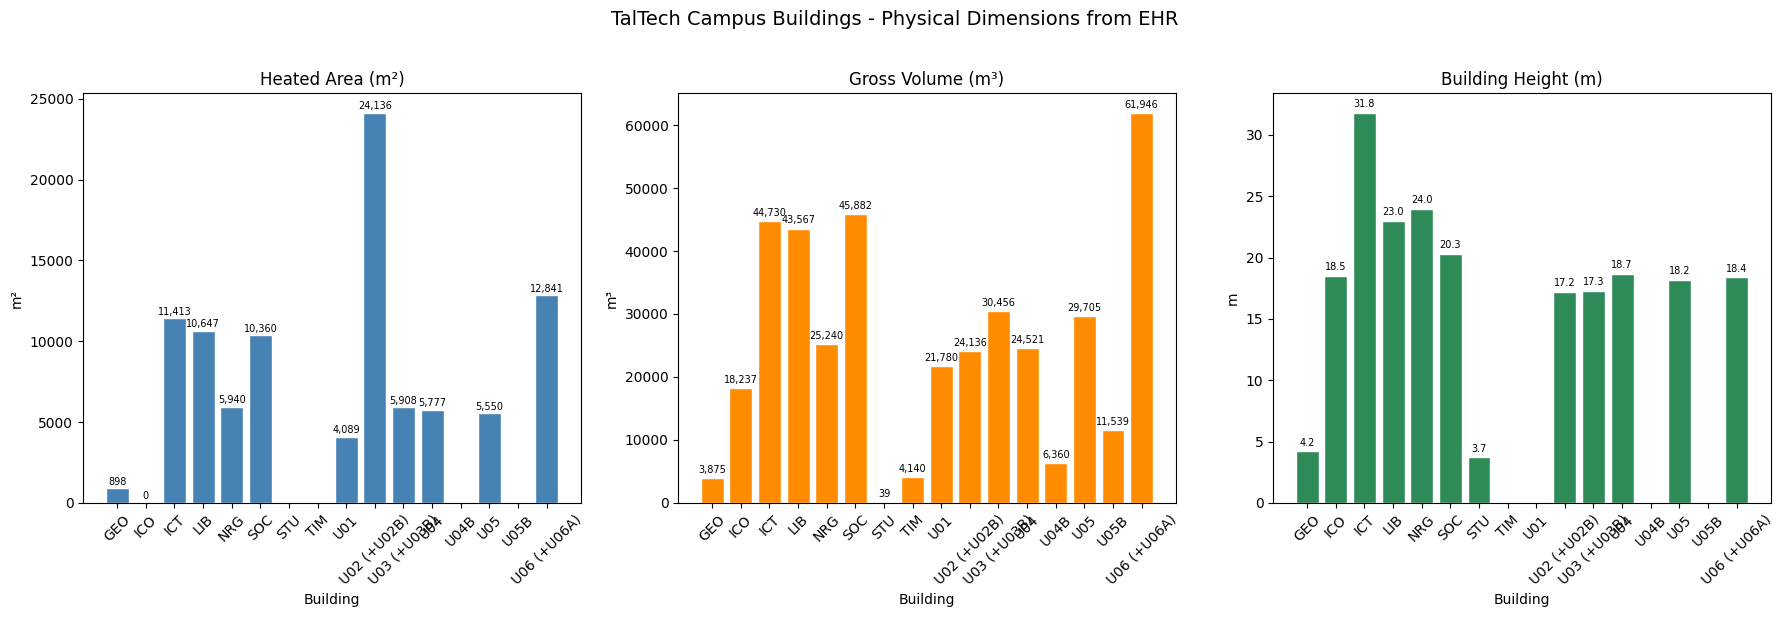

In [46]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 5)
matplotlib.rcParams['font.size'] = 10

# Sort by campus code for consistent ordering
plot_df = summary_df.sort_values("campus_code").copy()
codes = plot_df["campus_code"].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Heated area
ax = axes[0]
bars = ax.bar(codes, plot_df["heated_area_m2"].fillna(0), color="steelblue", edgecolor="white")
ax.set_title("Heated Area (m²)")
ax.set_ylabel("m²")
ax.set_xlabel("Building")
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, plot_df["heated_area_m2"]):
    if pd.notna(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f"{val:,.0f}", ha='center', va='bottom', fontsize=7)

# 2. Gross volume
ax = axes[1]
bars = ax.bar(codes, plot_df["gross_volume_m3"].fillna(0), color="darkorange", edgecolor="white")
ax.set_title("Gross Volume (m³)")
ax.set_ylabel("m³")
ax.set_xlabel("Building")
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, plot_df["gross_volume_m3"]):
    if pd.notna(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f"{val:,.0f}", ha='center', va='bottom', fontsize=7)

# 3. Height
ax = axes[2]
bars = ax.bar(codes, plot_df["height_m"].fillna(0), color="seagreen", edgecolor="white")
ax.set_title("Building Height (m)")
ax.set_ylabel("m")
ax.set_xlabel("Building")
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, plot_df["height_m"]):
    if pd.notna(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}", ha='center', va='bottom', fontsize=7)

plt.suptitle("TalTech Campus Buildings - Physical Dimensions from EHR", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

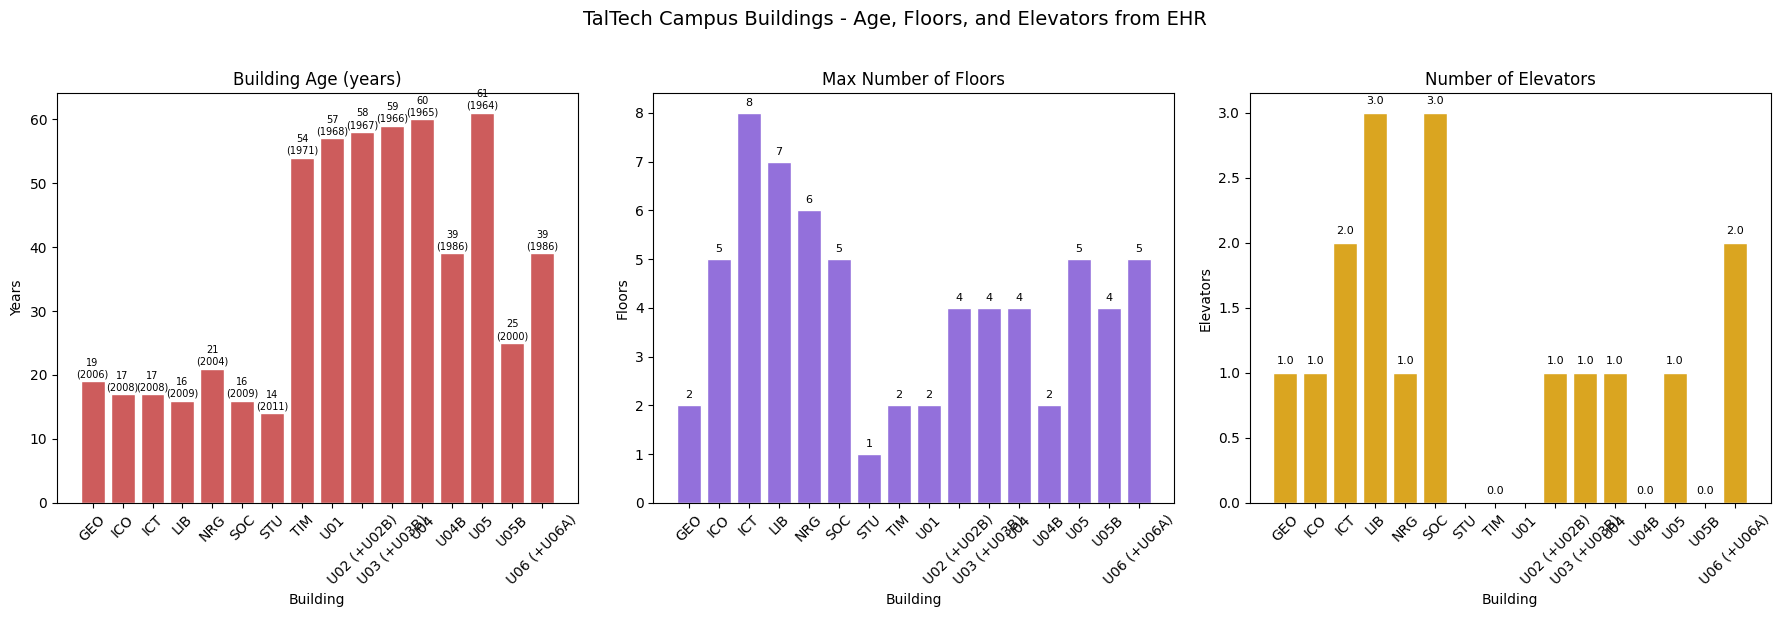

In [47]:
# Building age and number of floors comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. First use year / Building age
ax = axes[0]
bars = ax.bar(codes, plot_df["building_age_years"].fillna(0), color="indianred", edgecolor="white")
ax.set_title("Building Age (years)")
ax.set_ylabel("Years")
ax.set_xlabel("Building")
ax.tick_params(axis='x', rotation=45)
for bar, val, year in zip(bars, plot_df["building_age_years"], plot_df["first_use_year"]):
    if pd.notna(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val}\n({year})", ha='center', va='bottom', fontsize=7)

# 2. Max floors
ax = axes[1]
bars = ax.bar(codes, plot_df["max_floors"].fillna(0), color="mediumpurple", edgecolor="white")
ax.set_title("Max Number of Floors")
ax.set_ylabel("Floors")
ax.set_xlabel("Building")
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, plot_df["max_floors"]):
    if pd.notna(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val}", ha='center', va='bottom', fontsize=8)

# 3. Elevators
ax = axes[2]
bars = ax.bar(codes, plot_df["elevators"].fillna(0), color="goldenrod", edgecolor="white")
ax.set_title("Number of Elevators")
ax.set_ylabel("Elevators")
ax.set_xlabel("Building")
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, plot_df["elevators"]):
    if pd.notna(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val}", ha='center', va='bottom', fontsize=8)

plt.suptitle("TalTech Campus Buildings - Age, Floors, and Elevators from EHR", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/matplotlib/transforms.py:352: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


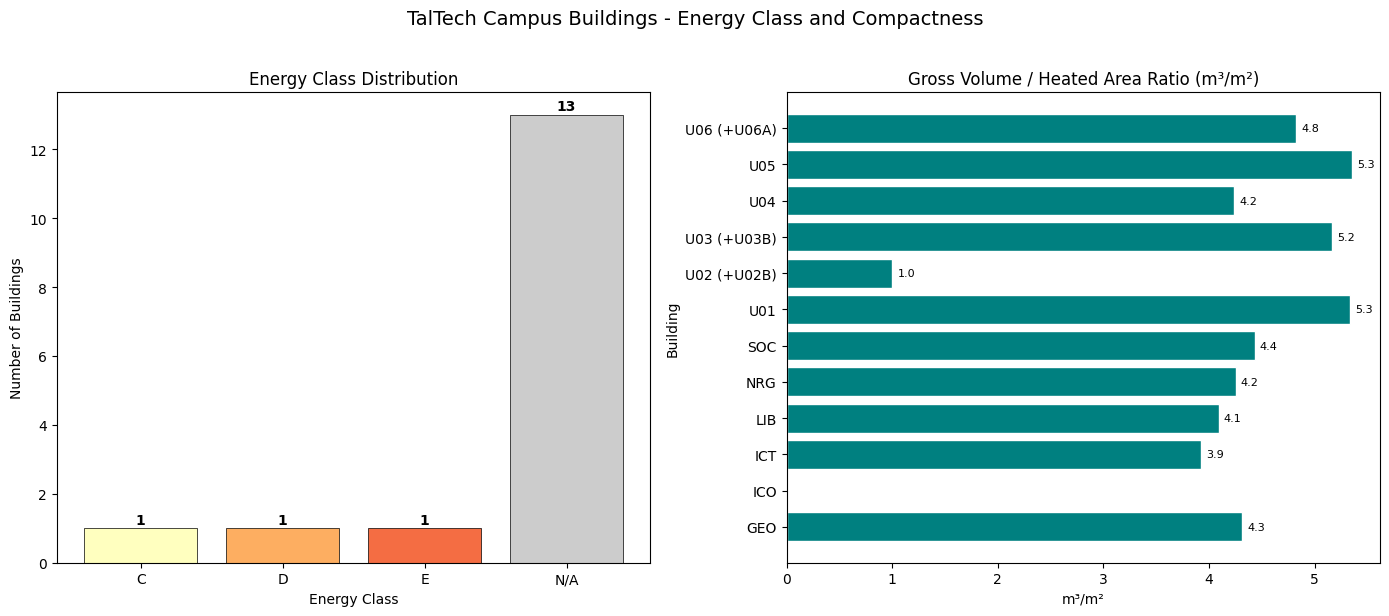

In [48]:
# Energy class distribution and volume-per-heated-area ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Energy class distribution
ax = axes[0]
energy_classes = summary_df["energy_class"].value_counts().sort_index()
colors_map = {"A": "#1a9641", "B": "#a6d96a", "C": "#ffffbf", "D": "#fdae61",
              "E": "#f46d43", "F": "#d73027", "G": "#a50026", "H": "#67001f", "N/A": "#cccccc"}
bar_colors = [colors_map.get(cls, "#999999") for cls in energy_classes.index]
ax.bar(energy_classes.index, energy_classes.values, color=bar_colors, edgecolor="black", linewidth=0.5)
ax.set_title("Energy Class Distribution")
ax.set_ylabel("Number of Buildings")
ax.set_xlabel("Energy Class")
for i, (cls, count) in enumerate(energy_classes.items()):
    ax.text(i, count + 0.05, str(count), ha='center', va='bottom', fontweight='bold')

# 2. Volume per heated area ratio (building "compactness" indicator)
ax = axes[1]
valid = plot_df[plot_df["volume_per_heated_area"].notna()]
bars = ax.barh(valid["campus_code"], valid["volume_per_heated_area"], color="teal", edgecolor="white")
ax.set_title("Gross Volume / Heated Area Ratio (m³/m²)")
ax.set_xlabel("m³/m²")
ax.set_ylabel("Building")
for bar, val in zip(bars, valid["volume_per_heated_area"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", ha='left', va='center', fontsize=8)

plt.suptitle("TalTech Campus Buildings - Energy Class and Compactness", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Save Raw EHR Data and Summary to Disk

Save the raw API responses for reproducibility (avoids re-querying the API) and the structured summary as CSV for easy use in modeling notebooks.

In [49]:
# Create output directory
EHR_OUTPUT_DIR = Path("data/ehr-building-data")
EHR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save raw JSON responses (one per building)
for campus_code, data in ehr_data.items():
    output_path = EHR_OUTPUT_DIR / f"{campus_code}_ehr_raw.json"
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f"  Saved: {output_path}")

# Save structured summary CSV
summary_output = EHR_OUTPUT_DIR / "ehr_building_summary.csv"
summary_df.to_csv(summary_output, index=False, encoding="utf-8")
print(f"\n  Summary CSV: {summary_output}")

# Save technical indicators CSV
tech_output = EHR_OUTPUT_DIR / "ehr_technical_indicators.csv"
tech_df.to_csv(tech_output, index=False, encoding="utf-8")
print(f"  Technical CSV: {tech_output}")

# Save energy certificates CSV
energy_output = EHR_OUTPUT_DIR / "ehr_energy_certificates.csv"
energy_df.to_csv(energy_output, index=False, encoding="utf-8")
print(f"  Energy CSV: {energy_output}")

print(f"\nDone! All files saved to {EHR_OUTPUT_DIR}/")

  Saved: data/ehr-building-data/U01_ehr_raw.json
  Saved: data/ehr-building-data/U02 (+U02B)_ehr_raw.json
  Saved: data/ehr-building-data/U03 (+U03B)_ehr_raw.json
  Saved: data/ehr-building-data/U04_ehr_raw.json
  Saved: data/ehr-building-data/U04B_ehr_raw.json
  Saved: data/ehr-building-data/U05_ehr_raw.json
  Saved: data/ehr-building-data/U05B_ehr_raw.json
  Saved: data/ehr-building-data/U06 (+U06A)_ehr_raw.json
  Saved: data/ehr-building-data/GEO_ehr_raw.json
  Saved: data/ehr-building-data/STU_ehr_raw.json
  Saved: data/ehr-building-data/NRG_ehr_raw.json
  Saved: data/ehr-building-data/LIB_ehr_raw.json
  Saved: data/ehr-building-data/SOC_ehr_raw.json
  Saved: data/ehr-building-data/ICT_ehr_raw.json
  Saved: data/ehr-building-data/ICO_ehr_raw.json
  Saved: data/ehr-building-data/TIM_ehr_raw.json

  Summary CSV: data/ehr-building-data/ehr_building_summary.csv
  Technical CSV: data/ehr-building-data/ehr_technical_indicators.csv
  Energy CSV: data/ehr-building-data/ehr_energy_certifica

## 11. Per-Building Detailed View

Show a detailed summary card for each building, combining all available EHR data in a readable format.

In [50]:
def print_building_card(campus_code: str, summary_df: pd.DataFrame, tech_df: pd.DataFrame,
                        energy_df: pd.DataFrame, building_codes_df: pd.DataFrame):
    """Print a detailed summary card for a single building."""
    row = summary_df[summary_df["campus_code"] == campus_code]
    if row.empty:
        print(f"No data for {campus_code}")
        return
    row = row.iloc[0]

    # Find the EHR URL
    bc_row = building_codes_df[building_codes_df["campus_code"].str.contains(campus_code, na=False, regex=False)]
    ehr_url = bc_row.iloc[0]["EHR register URL"] if not bc_row.empty else "N/A"

    print(f"{'='*70}")
    print(f"  {campus_code} - {row.get('name', 'N/A')}")
    print(f"{'='*70}")
    print(f"  Address:          {row.get('address', 'N/A')}")
    print(f"  EHR Code:         {row.get('ehr_code', 'N/A')}")
    print(f"  EHR URL:          {ehr_url}")
    print(f"  Building Type:    {row.get('building_type', 'N/A')}")
    print(f"  First Use:        {row.get('first_use_year', 'N/A')} (age: {row.get('building_age_years', 'N/A')} years)")
    print(f"  Status:           {row.get('status', 'N/A')}")
    print(f"  Energy Class:     {row.get('energy_class', 'N/A')}")
    print()
    print(f"  --- PHYSICAL DIMENSIONS ---")
    print(f"  Height:           {row.get('height_m', 'N/A')} m")
    print(f"  Width:            {row.get('width_m', 'N/A')} m")
    print(f"  Length:           {row.get('length_m', 'N/A')} m")
    print(f"  Gross Volume:     {row.get('gross_volume_m3', 'N/A')} m³")
    print(f"  Footprint Area:   {row.get('footprint_area_m2', 'N/A')} m²")
    print(f"  Heated Area:      {row.get('heated_area_m2', 'N/A')} m²")
    print(f"  Floors:           {row.get('min_floors', 'N/A')} - {row.get('max_floors', 'N/A')}")
    print(f"  Elevators:        {row.get('elevators', 'N/A')}")
    print(f"  Vol/Heated Area:  {row.get('volume_per_heated_area', 'N/A')} m³/m²")
    print()
    print(f"  --- ORIENTATION ---")
    print(f"  Main Axis:        {row.get('orientation_label', 'N/A')} (azimuth {row.get('orientation_azimuth_deg', 'N/A')}° from N)")
    print(f"  Longest Edge:     {row.get('longest_edge_m', 'N/A')} m")
    print()

    # Technical indicators
    tech_row = tech_df[tech_df["campus_code"] == campus_code]
    if not tech_row.empty:
        tech_row = tech_row.iloc[0]
        tech_cols = [col for col in tech_df.columns if not col.endswith("_est") and col != "campus_code"]
        print(f"  --- TECHNICAL SYSTEMS ---")
        for col in tech_cols:
            val = tech_row.get(col)
            if pd.notna(val):
                label = col.replace("_", " ").title()
                print(f"  {label:25s} {val}")
    print()

# Print cards for all buildings
for campus_code in sorted(ehr_data.keys()):
    print_building_card(campus_code, summary_df, tech_df, energy_df, building_codes_df)
    print()

  GEO - TTÜ HOONETEKOMPLEKSI III JA IV KORPUSE VAHEHOONE - KIVIMITE LADU
  Address:          Harju maakond, Tallinn, Mustamäe linnaosa, Ehitajate tee 5/9
  EHR Code:         120296180
  EHR URL:          https://livekluster.ehr.ee/ui/ehr/v1/building/120296180
  Building Type:    Muu haridus- või teadushoone
  First Use:        2006 (age: 19 years)
  Status:           Olemas
  Energy Class:     N/A

  --- PHYSICAL DIMENSIONS ---
  Height:           4.2 m
  Width:            12.8 m
  Length:           50.3 m
  Gross Volume:     3875.0 m³
  Footprint Area:   719.0 m²
  Heated Area:      898.2 m²
  Floors:           1.0 - 2
  Elevators:        1.0
  Vol/Heated Area:  4.31 m³/m²

  --- ORIENTATION ---
  Main Axis:        N-S (azimuth 167.6° from N)
  Longest Edge:     49.3 m

  --- TECHNICAL SYSTEMS ---
  Heating Supply Type       lokaalküte
  Foundation Type           madalvundament
  Structural Material       monteeritav raudbetoon + tellis + monoliitne raudbetoon + tellis, väikeplokk
  F

## 12. Summary Statistics

Overview of the numerical distributions across all buildings.

In [51]:
# Summary statistics for numerical columns
numeric_cols = [
    "height_m", "width_m", "length_m", "gross_volume_m3",
    "footprint_area_m2", "heated_area_m2", "net_closed_area_m2",
    "max_floors", "min_floors", "elevators", "building_age_years",
    "volume_per_heated_area", "compactness_ratio"
]
existing_num = [c for c in numeric_cols if c in summary_df.columns]

print("Summary statistics of building physical parameters:\n")
summary_df[existing_num].describe().round(2)

Summary statistics of building physical parameters:



/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,height_m,width_m,length_m,gross_volume_m3,footprint_area_m2,heated_area_m2,net_closed_area_m2,max_floors,min_floors,elevators,building_age_years,volume_per_heated_area,compactness_ratio
count,12.00,12.00,12.00,16.00,16.00,12.00,16.00,16.00,14.00,14.00,16.0,12.00,12.00
mean,17.94,37.42,65.06,24759.60,1644.86,8129.90,5550.25,4.12,2.57,1.21,35.75,inf,inf
std,7.71,26.37,34.00,17656.56,1066.52,6446.46,4095.93,1.96,2.10,0.97,19.39,NaN,NaN
min,3.70,2.50,6.40,39.00,18.90,0.00,14.40,1.00,1.00,0.00,14.0,1.00,0.08
25%,17.27,12.60,48.68,10244.25,780.50,5184.68,2286.80,2.00,1.00,1.00,17.0,4.20,0.23
50%,18.45,38.10,54.20,24328.50,1458.00,5924.00,5469.40,4.00,2.00,1.00,32.0,4.37,0.30
75%,20.98,49.00,87.58,33733.75,2178.12,10838.40,7949.12,5.00,2.75,1.75,57.25,5.20,0.40
max,31.80,95.30,126.30,61946.00,3940.40,24136.00,12841.20,8.00,8.00,3.00,61.0,inf,inf


## Notes / Observations

**Key findings about the EHR data:**

1. **API endpoint**: `https://livekluster.ehr.ee/api/building/v2/buildingData?ehr_code=<CODE>` - free, public, no authentication needed
2. **Coordinate system**: Building geometry uses L-EST97 (EPSG:3301) projected coordinates, not WGS84 lat/lon
3. **Building status**: Most buildings show "Püstitamisel" (under construction) even though they are in use - this seems to be a registry artifact related to ongoing renovation/reconstruction permits
4. **Energy classes**: Important for understanding baseline energy performance expectations
5. **Technical systems data**: Heating type (kaugküte = district heating), ventilation type, cooling - directly relevant to energy consumption modeling
6. **Derived features**: Volume-per-heated-area ratio and compactness ratio can serve as useful features for comparing thermal performance across buildings

**For the thesis modeling pipeline, the most useful features from EHR are:**
- `heated_area_m2` - the total heated/cooled floor area
- `gross_volume_m3` - total enclosed volume
- `height_m`, `width_m`, `length_m` - building envelope dimensions
- `max_floors` - number of stories
- `first_use_year` / `building_age_years` - proxy for construction era and insulation standards
- `energy_class` - official energy performance rating
- `wall_type`, `ventilation_type`, `heating_supply_type` - construction and systems characteristics
- `volume_per_heated_area` - indicator of average ceiling height / building form
- `orientation_azimuth_deg` / `orientation_label` - main axis direction (derived from polygon longest edge), relevant for solar gain and wind exposure